# Illumination Design with Equality-Constrained Least Squares

## 1. Introduction

This assignment studies an illumination design problem in which a set of lamps is used to light a rectangular area as uniformly as possible. The area is divided into a 25 × 25 grid, giving a total of:

**m = 25 × 25 = 625 pixels**

Each pixel represents a small region of the floor, and each lamp contributes a certain amount of illumination to every pixel.

There are **n = 10 lamps** placed at fixed three-dimensional positions. The objective is to choose the lamp power vector **p** so that the resulting illumination pattern is as close as possible to the desired uniform illumination pattern:

**l_des = 1**

The illumination model is linear and is written as:

**l = A p**

where:

- **l** is the vector of illumination levels at all 625 pixels.
- **A** is the 625 × 10 illumination matrix.
- **p** is the vector of the 10 lamp powers.

Each column of **A** represents the illumination pattern produced by one lamp operating at unit power. Each row of **A** describes how sensitive one pixel is to the powers of all lamps.

The entries of **A** are based on the inverse-square law. Therefore, the illumination contribution of lamp **j** to pixel **i** is proportional to:

**Aᵢⱼ ∝ 1 / dᵢⱼ²**

where **dᵢⱼ** is the three-dimensional distance between pixel **i** and lamp **j**.

The matrix **A** is scaled so that when all lamp powers are equal to one, the average illumination over the whole area is equal to one.

The main goal is to compare different choices of lamp powers and evaluate how well they approximate uniform illumination. In particular, we study:

1. the illumination obtained when all lamp powers are equal to one,
2. the unconstrained least-squares solution,
3. the constrained least-squares solution with nonnegative powers and total power equal to 10,
4. improved lamp positions found through random search.

## Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Number of lamps and pixels
n = 10
grid_size = 25
m = grid_size * grid_size

# Lamp positions: (x, y, height)
lamps = np.array([
    [4.1, 20.4, 4.0],
    [14.1, 21.3, 3.5],
    [22.6, 17.1, 6.0],
    [5.5, 12.3, 4.0],
    [12.2, 9.7, 4.0],
    [15.3, 13.8, 6.0],
    [21.3, 10.5, 5.5],
    [3.9, 3.3, 5.0],
    [13.1, 4.3, 5.0],
    [20.3, 4.2, 4.5]
])

In [4]:
# Pixel centers
x = np.arange(0.5, 25, 1)
y = np.arange(0.5, 25, 1)

X, Y = np.meshgrid(x, y)

pixel_positions = np.column_stack((X.ravel(), Y.ravel()))

pixel_positions.shape

(625, 2)

In [5]:
A = np.zeros((m, n))

for j in range(n):
    lamp_x = lamps[j, 0]
    lamp_y = lamps[j, 1]
    lamp_h = lamps[j, 2]
    
    distances_squared = (
        (pixel_positions[:, 0] - lamp_x)**2
        + (pixel_positions[:, 1] - lamp_y)**2
        + lamp_h**2
    )
    
    A[:, j] = 1 / distances_squared

In [7]:
# Scale A so that the average illumination is 1 when all lamp powers are equal to 1
p_ones = np.ones(n)
illumination_all_ones = A @ p_ones

scale_factor = 1 / np.mean(illumination_all_ones)
A = scale_factor * A

np.mean(A @ np.ones(n))

np.float64(1.0)

## Part A: Baseline Illumination

In the baseline case, all lamp powers are set equal to one. This means that every lamp operates with the same power.

**Baseline power vector:**

**p_base = [1, 1, 1, ..., 1]ᵀ**

Since there are 10 lamps, this vector has length 10.

The produced illumination is then calculated using the linear illumination model:

**l_base = A p_base**

where:

- **A** is the illumination matrix.
- **p_base** is the baseline lamp power vector.
- **l_base** is the illumination pattern produced when all lamps have power equal to one.

This illumination is compared with the desired uniform illumination:

**l_des = [1, 1, 1, ..., 1]ᵀ**

The goal is to measure how close **l_base** is to **l_des**. This is done using the Root Mean Squared error, defined as:

**RMS error = sqrt( mean( (l_base - l_des)² ) )**

A smaller RMS error means that the illumination is closer to the desired uniform pattern. A larger RMS error means that some regions are either too bright or too dark compared with the desired value.

In [8]:
# Baseline lamp powers
p_base = np.ones(n)

# Desired illumination
l_des = np.ones(m)

# Baseline illumination
l_base = A @ p_base

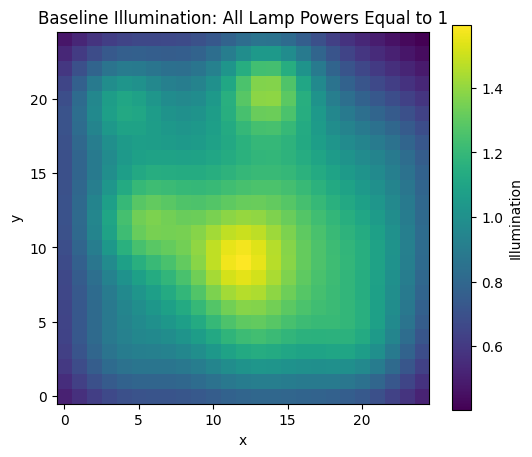

In [9]:
plt.figure(figsize=(6, 5))
plt.imshow(l_base.reshape(grid_size, grid_size), cmap='viridis', origin='lower')
plt.colorbar(label='Illumination')
plt.title('Baseline Illumination: All Lamp Powers Equal to 1')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

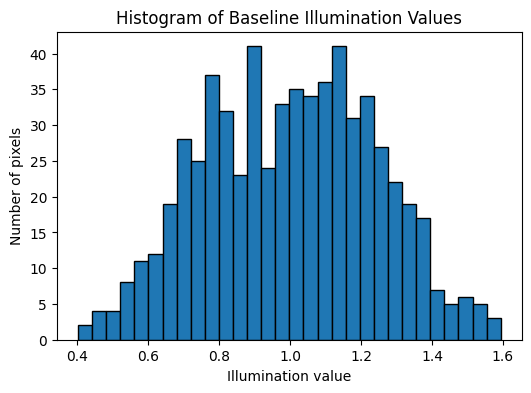

In [21]:
plt.figure(figsize=(6, 4))
plt.hist(l_base, bins=30, edgecolor='black')
plt.title('Histogram of Baseline Illumination Values')
plt.xlabel('Illumination value')
plt.ylabel('Number of pixels')
plt.show()

In [14]:
rms_base = np.sqrt(np.mean((l_base - l_des)**2))

min_base = np.min(l_base)
max_base = np.max(l_base)
mean_base = np.mean(l_base)
std_base = np.std(l_base)

baseline_stats = pd.DataFrame({
    "Statistic": [
        "RMS error",
        "Minimum illumination",
        "Maximum illumination",
        "Mean illumination",
        "Standard deviation"
    ],
    "Value": [
        rms_base,
        min_base,
        max_base,
        mean_base,
        std_base
    ]
})

baseline_stats.style.format({"Value": "{:.6f}"})

,Statistic,Value
0,RMS error,0.241741
1,Minimum illumination,0.401838
2,Maximum illumination,1.593974
3,Mean illumination,1.000000
4,Standard deviation,0.241741


### Baseline Results

For the baseline case, the mean illumination is equal to **1**. This is expected because the matrix **A** was scaled so that when all lamp powers are equal to one, the average illumination over the whole area is also equal to one.

However, even though the average illumination is correct, the lighting is not uniform across the room.

The baseline illumination values are:

| Quantity | Value |
|---|---:|
| Minimum illumination | 0.401838 |
| Maximum illumination | 1.593974 |
| Mean illumination | 1.000000 |
| RMS error | 0.241741 |

The minimum illumination is **0.401838**, which means that some regions receive much less light than the desired value of **1**. On the other hand, the maximum illumination is **1.593974**, meaning that some regions are much brighter than desired.

The RMS error is computed as:

**RMS error = sqrt( mean( (l_base - l_des)² ) )**

For the baseline case:

**RMS error = 0.241741**

This value represents the average deviation of the illumination from the desired uniform illumination.

Since the mean illumination is exactly **1**, the average error is zero. Therefore, in this baseline case, the RMS error is equal to the standard deviation of the illumination values. This confirms that the RMS error mainly measures how spread out the illumination values are around the desired value.

## Part B: Unconstrained Least Squares

In this part, we improve the illumination by solving an unconstrained least-squares problem. The goal is to find the lamp power vector **p** that makes the produced illumination **A p** as close as possible to the desired uniform illumination **l_des**.

The optimization problem is:

**minimize over p: ||A p - l_des||₂²**

This means that we want to minimize the squared difference between the actual illumination and the desired illumination.

The desired illumination is:

**l_des = [1, 1, 1, ..., 1]ᵀ**

The least-squares solution is the power vector that gives the smallest possible RMS error without adding any restrictions on the lamp powers.

In this part, there are no constraints on the values of **p**. Therefore, the powers can be positive, zero, or even negative. Although negative lamp powers are not physically realistic, the unconstrained solution is useful because it gives the best possible least-squares fit for the fixed lamp positions.

In [15]:
# Solve the unconstrained least squares problem
p_ls, residuals, rank, singular_values = np.linalg.lstsq(A, l_des, rcond=None)

# Illumination produced by the least squares powers
l_ls = A @ p_ls

In [16]:
p_ls_table = pd.DataFrame({
    "Lamp": np.arange(1, n + 1),
    "Power": p_ls
})

p_ls_table.style.format({"Power": "{:.6f}"})

,Lamp,Power
0,1,1.462110
1,2,0.787974
2,3,2.966410
3,4,0.743580
4,5,0.083173
5,6,0.212639
6,7,0.212184
7,8,2.051148
8,9,0.907603
9,10,1.472225


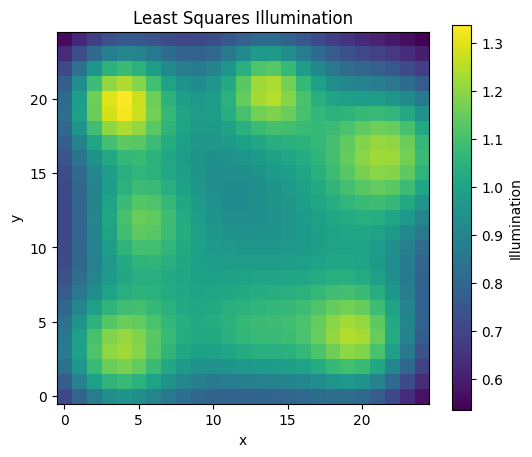

In [17]:
plt.figure(figsize=(6, 5))
plt.imshow(l_ls.reshape(grid_size, grid_size), cmap='viridis', origin='lower')
plt.colorbar(label='Illumination')
plt.title('Least Squares Illumination')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

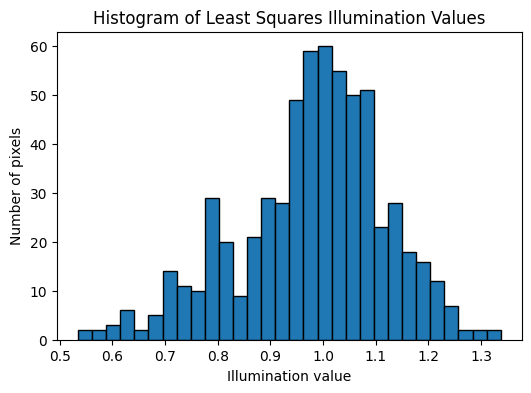

In [18]:
plt.figure(figsize=(6, 4))
plt.hist(l_ls, bins=30, edgecolor='black')
plt.title('Histogram of Least Squares Illumination Values')
plt.xlabel('Illumination value')
plt.ylabel('Number of pixels')
plt.show()

In [19]:
rms_ls = np.sqrt(np.mean((l_ls - l_des)**2))

min_ls = np.min(l_ls)
max_ls = np.max(l_ls)
mean_ls = np.mean(l_ls)
std_ls = np.std(l_ls)

ls_stats = pd.DataFrame({
    "Case": ["Least Squares"] * 5,
    "Statistic": [
        "RMS error",
        "Minimum illumination",
        "Maximum illumination",
        "Mean illumination",
        "Standard deviation"
    ],
    "Value": [
        rms_ls,
        min_ls,
        max_ls,
        mean_ls,
        std_ls
    ]
})

ls_stats.style.format({"Value": "{:.6f}"})

,Case,Statistic,Value
0,Least Squares,RMS error,0.140390
1,Least Squares,Minimum illumination,0.534786
2,Least Squares,Maximum illumination,1.337277
3,Least Squares,Mean illumination,0.980291
4,Least Squares,Standard deviation,0.139000


In [20]:
comparison_ab = pd.DataFrame({
    "Case": ["Baseline", "Least Squares"],
    "RMS error": [rms_base, rms_ls],
    "Minimum": [min_base, min_ls],
    "Maximum": [max_base, max_ls],
    "Mean": [mean_base, mean_ls],
    "Standard deviation": [std_base, std_ls]
})

comparison_ab.style.format({
    "RMS error": "{:.6f}",
    "Minimum": "{:.6f}",
    "Maximum": "{:.6f}",
    "Mean": "{:.6f}",
    "Standard deviation": "{:.6f}"
})

,Case,RMS error,Minimum,Maximum,Mean,Standard deviation
0,Baseline,0.241741,0.401838,1.593974,1.000000,0.241741
1,Least Squares,0.140390,0.534786,1.337277,0.980291,0.139000


### Least-Squares Results

The unconstrained least-squares solution gives a clear improvement compared with the baseline case.

In the baseline case, all lamp powers are equal to one, and the RMS error is:

**Baseline RMS error = 0.241741**

After solving the unconstrained least-squares problem, the RMS error decreases to:

**Least-squares RMS error = 0.140390**

This reduction shows that choosing different lamp powers produces an illumination pattern that is closer to the desired uniform illumination.

The comparison between the baseline and least-squares results is shown below:

| Quantity | Baseline | Least Squares |
|---|---:|---:|
| Minimum illumination | 0.401838 | 0.534786 |
| Maximum illumination | 1.593974 | 1.337277 |
| Mean illumination | 1.000000 | slightly below 1 |
| RMS error | 0.241741 | 0.140390 |

The minimum illumination increases from **0.401838** to **0.534786**, which means that the darkest regions become brighter. At the same time, the maximum illumination decreases from **1.593974** to **1.337277**, meaning that the brightest regions become less intense.

Therefore, the least-squares solution reduces both under-illumination and over-illumination. Although the mean illumination is slightly below **1**, the overall illumination is more uniform and closer to the desired illumination pattern.

In conclusion, the unconstrained least-squares solution improves the lighting distribution by reducing the RMS error and making the illumination values less spread out across the room.

## Part C: Equality-Constrained Least Squares with Fixed Total Power

In this part, we solve a least-squares problem with an additional equality constraint. The total power of all lamps must be equal to **10**.

This constraint is important because it keeps the total energy consumption fixed. Instead of allowing the optimization to choose any total amount of power, we force the sum of all lamp powers to remain constant.

The optimization problem is:

**minimize over p: ||A p - l_des||₂²**

subject to:

**sum(pᵢ) = 10**

or equivalently:

**p₁ + p₂ + ... + p₁₀ = 10**

where:

- **pᵢ** is the power of lamp **i**,
- **A p** is the produced illumination,
- **l_des** is the desired uniform illumination.

This problem can also be written in the standard equality-constrained least-squares form:

**minimize over p: ||A p - b||₂²**

subject to:

**C p = d**

For this assignment, the terms are:

| Symbol | Meaning |
|---|---|
| **b** | the desired illumination vector **l_des** |
| **C** | a row vector of ones, **[1, 1, ..., 1]** |
| **d** | the required total power, **10** |

Therefore, the equality constraint becomes:

**C p = d**

which means:

**[1, 1, ..., 1] p = 10**

This is exactly the same as saying that the sum of all lamp powers must be equal to **10**.

### KKT System

To solve the equality-constrained least-squares problem, we use the Karush-Kuhn-Tucker system, also called the **KKT system**.

The constrained problem is:

**minimize over p: ||A p - b||₂²**

subject to:

**C p = d**

The KKT system for this problem is:

```text
[ AᵀA   Cᵀ ] [ p ]   [ Aᵀb ]
[  C     0 ] [ λ ] = [  d   ]

In [23]:
# Standard form: min ||Ap - b||^2 subject to Cp = d
b = l_des

C = np.ones((1, n))
d = np.array([10.0])

C.shape

(1, 10)

In [24]:
# Construct the KKT matrix
KKT_matrix = np.block([
    [A.T @ A, C.T],
    [C, np.zeros((1, 1))]
])

KKT_rhs = np.concatenate([A.T @ b, d])

# Solve the KKT system
solution = np.linalg.solve(KKT_matrix, KKT_rhs)

p_kkt1 = solution[:n]
lambda_kkt1 = solution[n:]

In [25]:
constraint_value = np.sum(p_kkt1)

constraint_table = pd.DataFrame({
    "Constraint": ["sum of powers"],
    "Value": [constraint_value],
    "Target": [10.0]
})

constraint_table.style.format({
    "Value": "{:.6f}",
    "Target": "{:.6f}"
})

,Constraint,Value,Target
0,sum of powers,10.000000,10.000000


In [26]:
p_kkt1_table = pd.DataFrame({
    "Lamp": np.arange(1, n + 1),
    "Power": p_kkt1
})

p_kkt1_table.style.format({"Power": "{:.6f}"})

,Lamp,Power
0,1,1.349585
1,2,0.923521
2,3,2.434667
3,4,0.782698
4,5,0.393481
5,6,-0.238271
6,7,0.466428
7,8,1.769336
8,9,0.743818
9,10,1.374739


In [27]:
l_kkt1 = A @ p_kkt1

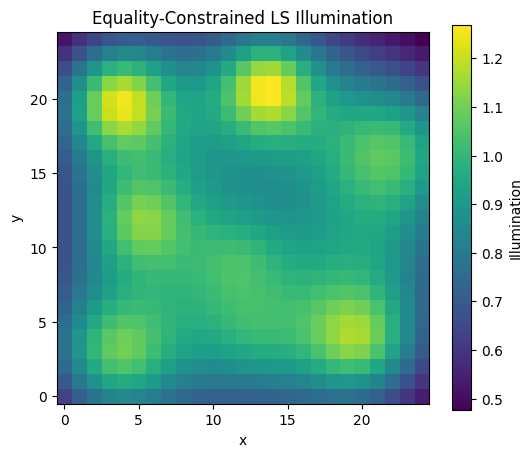

In [28]:
plt.figure(figsize=(6, 5))
plt.imshow(l_kkt1.reshape(grid_size, grid_size), cmap='viridis', origin='lower')
plt.colorbar(label='Illumination')
plt.title('Equality-Constrained LS Illumination')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

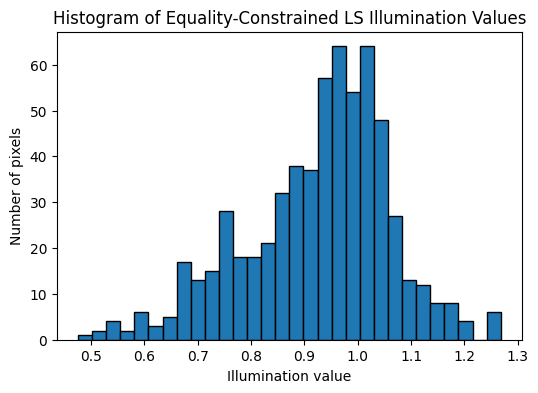

In [29]:
plt.figure(figsize=(6, 4))
plt.hist(l_kkt1, bins=30, edgecolor='black')
plt.title('Histogram of Equality-Constrained LS Illumination Values')
plt.xlabel('Illumination value')
plt.ylabel('Number of pixels')
plt.show()

In [30]:
rms_kkt1 = np.sqrt(np.mean((l_kkt1 - l_des)**2))

min_kkt1 = np.min(l_kkt1)
max_kkt1 = np.max(l_kkt1)
mean_kkt1 = np.mean(l_kkt1)
std_kkt1 = np.std(l_kkt1)

kkt1_stats = pd.DataFrame({
    "Statistic": [
        "RMS error",
        "Minimum illumination",
        "Maximum illumination",
        "Mean illumination",
        "Standard deviation"
    ],
    "Value": [
        rms_kkt1,
        min_kkt1,
        max_kkt1,
        mean_kkt1,
        std_kkt1
    ]
})

kkt1_stats.style.format({"Value": "{:.6f}"})

,Statistic,Value
0,RMS error,0.155559
1,Minimum illumination,0.476075
2,Maximum illumination,1.268019
3,Mean illumination,0.925871
4,Standard deviation,0.136760


In [31]:
comparison_abc = pd.DataFrame({
    "Case": ["Baseline", "Least Squares", "KKT total power"],
    "RMS error": [rms_base, rms_ls, rms_kkt1],
    "Minimum": [min_base, min_ls, min_kkt1],
    "Maximum": [max_base, max_ls, max_kkt1],
    "Mean": [mean_base, mean_ls, mean_kkt1],
    "Standard deviation": [std_base, std_ls, std_kkt1]
})

comparison_abc.style.format({
    "RMS error": "{:.6f}",
    "Minimum": "{:.6f}",
    "Maximum": "{:.6f}",
    "Mean": "{:.6f}",
    "Standard deviation": "{:.6f}"
})

,Case,RMS error,Minimum,Maximum,Mean,Standard deviation
0,Baseline,0.241741,0.401838,1.593974,1.000000,0.241741
1,Least Squares,0.140390,0.534786,1.337277,0.980291,0.139000
2,KKT total power,0.155559,0.476075,1.268019,0.925871,0.136760


### Equality-Constrained Results

The equality constraint is satisfied because the sum of all lamp powers is equal to **10**.

**Total lamp power = 10**

The RMS error for the equality-constrained solution is:

**Equality-constrained RMS error = 0.155559**

This result improves the baseline illumination, but it is not as good as the unconstrained least-squares result.

| Case | RMS Error |
|---|---:|
| Baseline | 0.241741 |
| Unconstrained least squares | 0.140390 |
| Equality-constrained least squares | 0.155559 |

The equality-constrained solution gives a smaller RMS error than the baseline case. This means that optimizing the lamp powers still improves the illumination compared with using equal power for all lamps.

However, the RMS error is larger than the unconstrained least-squares RMS error. This is expected because the constrained problem has fewer degrees of freedom. The optimizer must satisfy the fixed total power condition:

**p₁ + p₂ + ... + p₁₀ = 10**

As a result, it cannot choose any power vector freely.

One important observation is that one of the lamp powers is negative. This happens because, in this part, only the equality constraint was imposed. The optimization required the total power to be equal to **10**, but it did not require each individual lamp power to be nonnegative.

In other words, the constraint was:

**sum(pᵢ) = 10**

but we did not include the physical constraint:

**pᵢ ≥ 0 for every lamp i**

Therefore, the solution is mathematically valid for the equality-constrained least-squares problem, but it is not fully physically realistic. A negative lamp power does not make sense in a real lighting system, so an additional nonnegativity constraint is needed for a physically meaningful solution.

## Part D: Equality Constraints for Balanced Illumination

In this part, we add two extra equality constraints to make the illumination more balanced across the room.

The purpose of these constraints is to avoid lighting patterns that are too bright on one side and too dark on the other side. Instead of only controlling the total power, we also control how the illumination is distributed around the center of the room.

The center of the room is:

**x_center = 12.5**

**y_center = 12.5**

For each pixel, we measure its horizontal and vertical distance from the center:

**g_x,i = x_i - x_center**

**g_y,i = y_i - y_center**

where:

- **x_i** is the x-coordinate of pixel **i**,
- **y_i** is the y-coordinate of pixel **i**,
- **g_x,i** measures how far pixel **i** is from the center in the x-direction,
- **g_y,i** measures how far pixel **i** is from the center in the y-direction.

The three equality constraints are:

**1. Total power constraint**

**p₁ + p₂ + ... + p₁₀ = 10**

This ensures that the total energy consumption of the lamps is fixed.

**2. Balance constraint in the x-direction**

**g_xᵀ A p = 0**

This constraint forces the illumination to be balanced between the left and right sides of the room.

**3. Balance constraint in the y-direction**

**g_yᵀ A p = 0**

This constraint forces the illumination to be balanced between the bottom and top sides of the room.

Since **A p** is the illumination vector, the terms **g_xᵀ A p** and **g_yᵀ A p** measure whether the illumination is biased toward one side of the room.

Therefore:

- If **g_xᵀ A p > 0**, the illumination is biased toward larger x-values.
- If **g_xᵀ A p < 0**, the illumination is biased toward smaller x-values.
- If **g_xᵀ A p = 0**, the illumination is balanced in the x-direction.

Similarly:

- If **g_yᵀ A p > 0**, the illumination is biased toward larger y-values.
- If **g_yᵀ A p < 0**, the illumination is biased toward smaller y-values.
- If **g_yᵀ A p = 0**, the illumination is balanced in the y-direction.

With these constraints, the optimization problem still tries to minimize the illumination error, but it also forces the total power and the spatial balance conditions to be satisfied.

The constraints can be written in the standard form **C p = d**, where **C** contains the three equality constraints and **d** contains their required values.

**C = [[1ᵀ], [g_xᵀ A], [g_yᵀ A]]**

and

**d = [10, 0, 0]ᵀ**

So the complete constraint system is:

**[[1ᵀ], [g_xᵀ A], [g_yᵀ A]] p = [10, 0, 0]ᵀ**

The first row enforces the total power constraint, while the second and third rows enforce balance in the x-direction and y-direction.

In [32]:
# Coordinates of pixel centers
x_pixels = pixel_positions[:, 0]
y_pixels = pixel_positions[:, 1]

# Center of the room
x_bar = 12.5
y_bar = 12.5

# Vectors measuring distance from the center
g_x = x_pixels - x_bar
g_y = y_pixels - y_bar

In [34]:
# Constraint matrix for balanced illumination
C_balanced = np.vstack([
    np.ones(n),
    g_x @ A,
    g_y @ A
])

d_balanced = np.array([10.0, 0.0, 0.0])

C_balanced.shape

(3, 10)

In [35]:
# Construct the KKT system
KKT_matrix_balanced = np.block([
    [A.T @ A, C_balanced.T],
    [C_balanced, np.zeros((3, 3))]
])

KKT_rhs_balanced = np.concatenate([A.T @ l_des, d_balanced])

# Solve the KKT system
solution_balanced = np.linalg.solve(KKT_matrix_balanced, KKT_rhs_balanced)

p_kkt2 = solution_balanced[:n]
lambda_kkt2 = solution_balanced[n:]

In [36]:
p_kkt2_table = pd.DataFrame({
    "Lamp": np.arange(1, n + 1),
    "Power": p_kkt2
})

p_kkt2_table.style.format({"Power": "{:.6f}"})

,Lamp,Power
0,1,1.360142
1,2,0.946524
2,3,2.526439
3,4,0.772571
4,5,0.407882
5,6,-0.264675
6,7,0.464580
7,8,1.705041
8,9,0.715642
9,10,1.365855


In [37]:
constraint_values_balanced = C_balanced @ p_kkt2

balanced_constraints_table = pd.DataFrame({
    "Constraint": [
        "sum of powers",
        "x-balance",
        "y-balance"
    ],
    "Value": constraint_values_balanced,
    "Target": d_balanced
})

balanced_constraints_table.style.format({
    "Value": "{:.6e}",
    "Target": "{:.6e}"
})

,Constraint,Value,Target
0,sum of powers,1.000000e+01,1.000000e+01
1,x-balance,5.684342e-14,0.000000e+00
2,y-balance,0.000000e+00,0.000000e+00


In [38]:
l_kkt2 = A @ p_kkt2

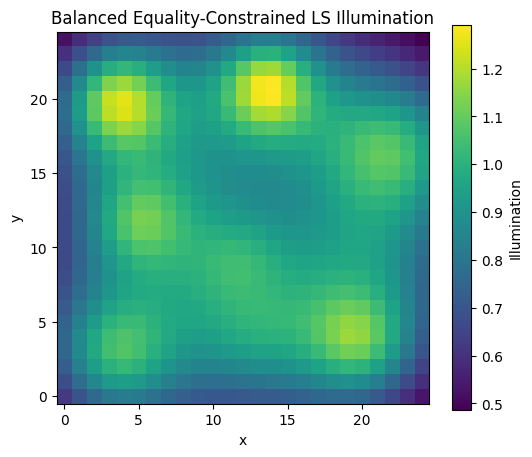

In [39]:
plt.figure(figsize=(6, 5))
plt.imshow(l_kkt2.reshape(grid_size, grid_size), cmap='viridis', origin='lower')
plt.colorbar(label='Illumination')
plt.title('Balanced Equality-Constrained LS Illumination')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

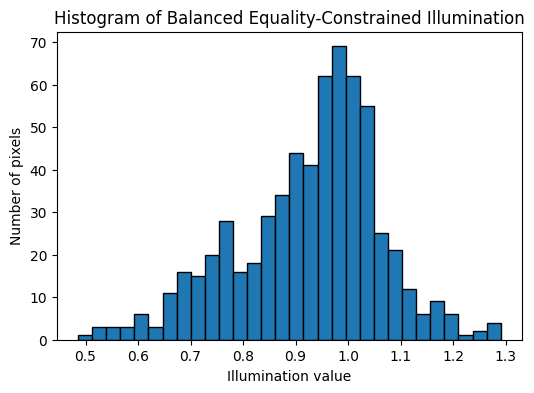

In [40]:
plt.figure(figsize=(6, 4))
plt.hist(l_kkt2, bins=30, edgecolor='black')
plt.title('Histogram of Balanced Equality-Constrained Illumination')
plt.xlabel('Illumination value')
plt.ylabel('Number of pixels')
plt.show()

In [41]:
rms_kkt2 = np.sqrt(np.mean((l_kkt2 - l_des)**2))

min_kkt2 = np.min(l_kkt2)
max_kkt2 = np.max(l_kkt2)
mean_kkt2 = np.mean(l_kkt2)
std_kkt2 = np.std(l_kkt2)

kkt2_stats = pd.DataFrame({
    "Statistic": [
        "RMS error",
        "Minimum illumination",
        "Maximum illumination",
        "Mean illumination",
        "Standard deviation"
    ],
    "Value": [
        rms_kkt2,
        min_kkt2,
        max_kkt2,
        mean_kkt2,
        std_kkt2
    ]
})

kkt2_stats.style.format({"Value": "{:.6f}"})

,Statistic,Value
0,RMS error,0.156031
1,Minimum illumination,0.485752
2,Maximum illumination,1.290842
3,Mean illumination,0.925781
4,Standard deviation,0.137249


In [42]:
comparison_abcd = pd.DataFrame({
    "Case": [
        "Baseline",
        "Least Squares",
        "KKT total power",
        "KKT balanced"
    ],
    "RMS error": [
        rms_base,
        rms_ls,
        rms_kkt1,
        rms_kkt2
    ],
    "Minimum": [
        min_base,
        min_ls,
        min_kkt1,
        min_kkt2
    ],
    "Maximum": [
        max_base,
        max_ls,
        max_kkt1,
        max_kkt2
    ],
    "Mean": [
        mean_base,
        mean_ls,
        mean_kkt1,
        mean_kkt2
    ],
    "Standard deviation": [
        std_base,
        std_ls,
        std_kkt1,
        std_kkt2
    ]
})

comparison_abcd.style.format({
    "RMS error": "{:.6f}",
    "Minimum": "{:.6f}",
    "Maximum": "{:.6f}",
    "Mean": "{:.6f}",
    "Standard deviation": "{:.6f}"
})

,Case,RMS error,Minimum,Maximum,Mean,Standard deviation
0,Baseline,0.241741,0.401838,1.593974,1.000000,0.241741
1,Least Squares,0.140390,0.534786,1.337277,0.980291,0.139000
2,KKT total power,0.155559,0.476075,1.268019,0.925871,0.136760
3,KKT balanced,0.156031,0.485752,1.290842,0.925781,0.137249


The balanced equality-constrained solution satisfies all three constraints. The total lamp power is equal to **10**, and the balance constraints in the x-direction and y-direction are both approximately equal to **0**.

The value of the x-balance constraint is very small:

**x-balance = 5.68 × 10⁻¹⁴**

This value is not exactly zero only because of numerical precision. Since it is extremely close to zero, it can be considered zero in practice.

The RMS error of the balanced solution is:

**Balanced equality-constrained RMS error = 0.156031**

This is very close to the RMS error of the previous equality-constrained solution:

**Previous equality-constrained RMS error = 0.155559**

Therefore, adding the balancing constraints does not significantly change the RMS error.

However, the purpose of the additional constraints is not only to reduce the RMS error. Their main purpose is to force the illumination to be more balanced around the center of the room. In other words, the solution avoids being strongly biased toward one side of the room.

One important observation is that the solution still contains one negative lamp power. This happens because only equality constraints were imposed. The optimization enforces the total power and balance conditions, but it does not enforce the physical condition:

**pᵢ ≥ 0 for every lamp i**

Therefore, the balanced solution is mathematically valid, but it is still not fully physically realistic. To obtain a physically meaningful lighting design, nonnegativity constraints must also be included.

## Part E: Exact Illumination at Selected Pixels

In this part, we add exact illumination constraints at three selected pixels. These pixels can represent important locations in the room where the illumination must be exactly equal to the desired value.

We keep the total power constraint:

**p₁ + p₂ + ... + p₁₀ = 10**

This ensures that the total lamp power remains fixed.

We also select three pixels, called **i₁**, **i₂**, and **i₃**, where the illumination must be exactly equal to **1**.

The exact illumination constraints are:

**(A p)_i₁ = 1**

**(A p)_i₂ = 1**

**(A p)_i₃ = 1**

Here, **(A p)_i** means the illumination value at pixel **i**.

These constraints force the optimized illumination pattern to match the desired illumination exactly at the selected pixels. The rest of the pixels are still optimized in the least-squares sense, meaning that the solution tries to make the overall illumination as close as possible to uniform.

The constraints can be written in the standard form:

**C p = d**

where **C** contains the total power constraint and the three selected rows of the illumination matrix **A**.

If the selected pixels are **i₁**, **i₂**, and **i₃**, then:

**C = [1ᵀ; A_i₁; A_i₂; A_i₃]**

and

**d = [10, 1, 1, 1]ᵀ**

Therefore, the complete constraint system is:

**[1ᵀ; A_i₁; A_i₂; A_i₃] p = [10, 1, 1, 1]ᵀ**

The first row enforces the total power constraint, while the next three rows force the illumination at the selected pixels to be exactly equal to the desired value **1**.

In [43]:
# Selected important pixel coordinates
selected_coordinates = np.array([
    [6.5, 6.5],
    [12.5, 12.5],
    [18.5, 18.5]
])

# Find the indices of the selected pixels
selected_indices = []

for coord in selected_coordinates:
    distances = np.sum((pixel_positions - coord)**2, axis=1)
    selected_indices.append(np.argmin(distances))

selected_indices = np.array(selected_indices)

selected_pixels_table = pd.DataFrame({
    "Selected pixel": [1, 2, 3],
    "x": selected_coordinates[:, 0],
    "y": selected_coordinates[:, 1],
    "Index": selected_indices
})

selected_pixels_table

,Selected pixel,x,y,Index
0,1,6.5,6.5,156
1,2,12.5,12.5,312
2,3,18.5,18.5,468


In [45]:
# Construct constraints for exact illumination at selected pixels
C_exact = np.vstack([
    np.ones(n),
    A[selected_indices, :]
])

d_exact = np.array([10.0, 1.0, 1.0, 1.0])

C_exact.shape

(4, 10)

For this problem, the constraint matrix **C** contains the total power constraint and the three exact illumination constraints at the selected pixels.

**C = [[1ᵀ], [A_i₁,:], [A_i₂,:], [A_i₃,:]]**

and

**d = [10, 1, 1, 1]ᵀ**

So the complete constraint system is:

**[[1ᵀ], [A_i₁,:], [A_i₂,:], [A_i₃,:]] p = [10, 1, 1, 1]ᵀ**

The first row of **C** enforces the total lamp power condition. The next three rows are the rows of **A** corresponding to the selected pixels **i₁**, **i₂**, and **i₃**. These rows force the illumination at those pixels to be exactly equal to **1**.

In [54]:
# Construct the KKT system
KKT_matrix_exact = np.block([
    [A.T @ A, C_exact.T],
    [C_exact, np.zeros((4, 4))]
])

KKT_rhs_exact = np.concatenate([A.T @ l_des, d_exact])

# Solve the KKT system
solution_exact = np.linalg.solve(KKT_matrix_exact, KKT_rhs_exact)

p_exact = solution_exact[:n]
lambda_exact = solution_exact[n:]

In [47]:
constraint_values_exact = C_exact @ p_exact

exact_constraints_table = pd.DataFrame({
    "Constraint": [
        "sum of powers",
        "pixel 1 illumination",
        "pixel 2 illumination",
        "pixel 3 illumination"
    ],
    "Value": constraint_values_exact,
    "Target": d_exact
})

exact_constraints_table.style.format({
    "Value": "{:.6f}",
    "Target": "{:.6f}"
})

,Constraint,Value,Target
0,sum of powers,10.000000,10.000000
1,pixel 1 illumination,1.000000,1.000000
2,pixel 2 illumination,1.000000,1.000000
3,pixel 3 illumination,1.000000,1.000000


In [48]:
l_exact = A @ p_exact

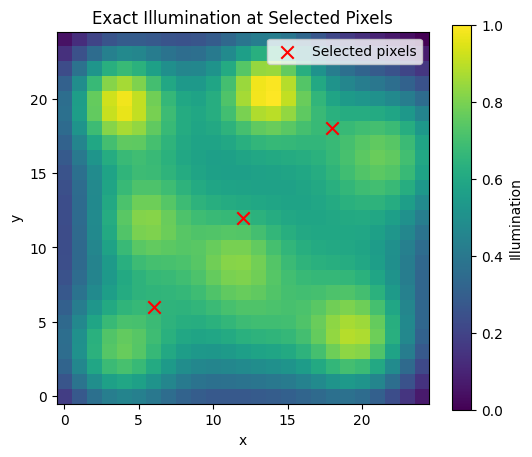

In [49]:
plt.figure(figsize=(6, 5))
plt.imshow(l_exact.reshape(grid_size, grid_size), cmap='viridis', origin='lower')
plt.scatter(
    selected_coordinates[:, 0] - 0.5,
    selected_coordinates[:, 1] - 0.5,
    color='red',
    marker='x',
    s=80,
    label='Selected pixels'
)
plt.colorbar(label='Illumination')
plt.title('Exact Illumination at Selected Pixels')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

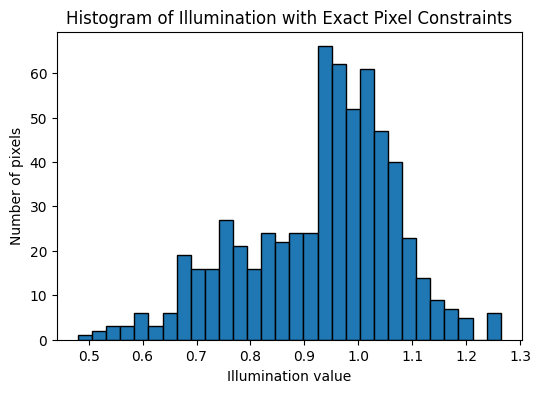

In [50]:
plt.figure(figsize=(6, 4))
plt.hist(l_exact, bins=30, edgecolor='black')
plt.title('Histogram of Illumination with Exact Pixel Constraints')
plt.xlabel('Illumination value')
plt.ylabel('Number of pixels')
plt.show()

In [51]:
rms_exact = np.sqrt(np.mean((l_exact - l_des)**2))

min_exact = np.min(l_exact)
max_exact = np.max(l_exact)
mean_exact = np.mean(l_exact)
std_exact = np.std(l_exact)

exact_stats = pd.DataFrame({
    "Statistic": [
        "RMS error",
        "Minimum illumination",
        "Maximum illumination",
        "Mean illumination",
        "Standard deviation"
    ],
    "Value": [
        rms_exact,
        min_exact,
        max_exact,
        mean_exact,
        std_exact
    ]
})

exact_stats.style.format({"Value": "{:.6f}"})

,Statistic,Value
0,RMS error,0.157275
1,Minimum illumination,0.480218
2,Maximum illumination,1.264387
3,Mean illumination,0.930183
4,Standard deviation,0.140929


In [52]:
comparison_abcde = pd.DataFrame({
    "Case": [
        "Baseline",
        "Least Squares",
        "KKT total power",
        "KKT balanced",
        "Exact pixels"
    ],
    "RMS error": [
        rms_base,
        rms_ls,
        rms_kkt1,
        rms_kkt2,
        rms_exact
    ],
    "Minimum": [
        min_base,
        min_ls,
        min_kkt1,
        min_kkt2,
        min_exact
    ],
    "Maximum": [
        max_base,
        max_ls,
        max_kkt1,
        max_kkt2,
        max_exact
    ],
    "Mean": [
        mean_base,
        mean_ls,
        mean_kkt1,
        mean_kkt2,
        mean_exact
    ],
    "Standard deviation": [
        std_base,
        std_ls,
        std_kkt1,
        std_kkt2,
        std_exact
    ]
})

comparison_abcde.style.format({
    "RMS error": "{:.6f}",
    "Minimum": "{:.6f}",
    "Maximum": "{:.6f}",
    "Mean": "{:.6f}",
    "Standard deviation": "{:.6f}"
})

,Case,RMS error,Minimum,Maximum,Mean,Standard deviation
0,Baseline,0.241741,0.401838,1.593974,1.000000,0.241741
1,Least Squares,0.140390,0.534786,1.337277,0.980291,0.139000
2,KKT total power,0.155559,0.476075,1.268019,0.925871,0.136760
3,KKT balanced,0.156031,0.485752,1.290842,0.925781,0.137249
4,Exact pixels,0.157275,0.480218,1.264387,0.930183,0.140929


The selected pixels have coordinates **(6.5, 6.5)**, **(12.5, 12.5)**, and **(18.5, 18.5)**. These points were chosen as representative important locations in the room where the illumination should match the desired value exactly.

The equality constraints are satisfied exactly. The total lamp power is equal to **10**, and the illumination values at the three selected pixels are all equal to **1**.

This confirms that the KKT system correctly enforces the required constraints:

**total power = 10**

**illumination at (6.5, 6.5) = 1**

**illumination at (12.5, 12.5) = 1**

**illumination at (18.5, 18.5) = 1**

The RMS error for this case is:

**RMS error = 0.157275**

This value is slightly larger than the RMS errors of the previous constrained cases. This is expected because imposing exact illumination at selected pixels reduces the freedom of the optimization problem. The optimizer must satisfy these local illumination requirements exactly, even if this slightly worsens the overall illumination error across the room.

In this case, all lamp powers are positive. Therefore, the solution is physically meaningful with respect to the lamp powers, since no lamp is assigned a negative power.

## Part G: Design Challenge with Equality Constraints

In this part, we try to improve the illumination by changing the positions of the lamps. Unlike the previous parts, the lamp locations are no longer fixed. Instead, we randomly generate new lamp positions and test whether they produce a better illumination pattern.

Each lamp must remain inside the room. Therefore, for every lamp **j**, the horizontal coordinates must satisfy:

**0 ≤ x_j ≤ 25**

**0 ≤ y_j ≤ 25**

The height of each lamp must also stay within the allowed range:

**4 ≤ h_j ≤ 6**

For each random lamp configuration, we build a new illumination matrix **A** using the inverse-square distance model. After constructing **A**, we scale it so that when all lamp powers are equal to one, the average illumination is equal to **1**.

Then, for each random configuration, we solve the equality-constrained least-squares problem:

**minimize over p: ||A p - 1||₂²**

subject to the fixed total power constraint:

**p₁ + p₂ + ... + p₁₀ = 10**

This constraint ensures that every tested configuration uses the same total amount of lamp power.

After solving the constrained problem, we check whether all lamp powers are positive. Only solutions with physically meaningful lamp powers are kept:

**p_j > 0 for every lamp j**

The goal is to find a new random lamp configuration that gives a smaller RMS error than the original lamp configuration. In other words, we search for lamp positions that produce a more uniform illumination pattern while still satisfying the equality constraint and using only positive lamp powers.

In [56]:
def construct_A(lamps, pixel_positions, m, n):
    A = np.zeros((m, n))
    
    for j in range(n):
        lamp_x = lamps[j, 0]
        lamp_y = lamps[j, 1]
        lamp_h = lamps[j, 2]
        
        distance_squared = (
            (pixel_positions[:, 0] - lamp_x)**2
            + (pixel_positions[:, 1] - lamp_y)**2
            + lamp_h**2
        )
        
        A[:, j] = 1 / distance_squared
    
    # Scale A so that mean illumination is 1 when all lamp powers are 1
    A = A / np.mean(A @ np.ones(n))
    
    return A


def solve_total_power_kkt(A, l_des, total_power=10.0):
    n = A.shape[1]
    
    C = np.ones((1, n))
    d = np.array([total_power])
    
    KKT_matrix = np.block([
        [A.T @ A, C.T],
        [C, np.zeros((1, 1))]
    ])
    
    KKT_rhs = np.concatenate([A.T @ l_des, d])
    
    solution = np.linalg.solve(KKT_matrix, KKT_rhs)
    
    p = solution[:n]
    
    return p

In [57]:
# Number of random configurations
num_trials = 100

best_rms = np.inf
best_lamps = None
best_p = None
best_A = None
best_l = None

np.random.seed(1)

for trial in range(num_trials):
    # Random lamp positions
    random_lamps = np.zeros((n, 3))
    random_lamps[:, 0] = np.random.uniform(0, 25, n)   # x coordinates
    random_lamps[:, 1] = np.random.uniform(0, 25, n)   # y coordinates
    random_lamps[:, 2] = np.random.uniform(4, 6, n)    # heights
    
    # Construct and scale A for this configuration
    A_random = construct_A(random_lamps, pixel_positions, m, n)
    
    # Solve equality-constrained LS
    p_random = solve_total_power_kkt(A_random, l_des, total_power=10.0)
    
    # Keep only physically meaningful solutions
    if np.all(p_random > 0):
        l_random = A_random @ p_random
        rms_random = np.sqrt(np.mean((l_random - l_des)**2))
        
        if rms_random < best_rms:
            best_rms = rms_random
            best_lamps = random_lamps
            best_p = p_random
            best_A = A_random
            best_l = l_random

In [58]:
if best_lamps is None:
    print("No positive-power solution was found.")
else:
    print("Best RMS error:", best_rms)
    print("Number of trials:", num_trials)

Best RMS error: 0.1271447474919971
Number of trials: 100


In [59]:
best_lamps_table = pd.DataFrame({
    "Lamp": np.arange(1, n + 1),
    "x": best_lamps[:, 0],
    "y": best_lamps[:, 1],
    "height": best_lamps[:, 2]
})

best_lamps_table.style.format({
    "x": "{:.6f}",
    "y": "{:.6f}",
    "height": "{:.6f}"
})

,Lamp,x,y,height
0,1,4.711710,5.689943,4.551206
1,2,17.143922,3.635091,5.849482
2,3,8.880235,5.085846,4.773978
3,4,24.355316,22.408064,4.985762
4,5,3.069303,21.827359,4.508876
5,6,4.689247,17.507236,5.769933
6,7,22.236062,11.762442,4.766527
7,8,14.585158,20.678400,4.595149
8,9,7.731160,12.395660,5.435190
9,10,0.019110,9.087217,4.381740


In [60]:
best_p_table = pd.DataFrame({
    "Lamp": np.arange(1, n + 1),
    "Power": best_p
})

best_p_table.style.format({"Power": "{:.6f}"})

,Lamp,Power
0,1,0.938070
1,2,2.228753
2,3,0.375342
3,4,1.407254
4,5,1.173273
5,6,0.640567
6,7,1.105156
7,8,1.130133
8,9,0.343416
9,10,0.658036


In [61]:
rms_best = np.sqrt(np.mean((best_l - l_des)**2))

min_best = np.min(best_l)
max_best = np.max(best_l)
mean_best = np.mean(best_l)
std_best = np.std(best_l)

best_stats = pd.DataFrame({
    "Statistic": [
        "RMS error",
        "Minimum illumination",
        "Maximum illumination",
        "Mean illumination",
        "Standard deviation"
    ],
    "Value": [
        rms_best,
        min_best,
        max_best,
        mean_best,
        std_best
    ]
})

best_stats.style.format({"Value": "{:.6f}"})

,Statistic,Value
0,RMS error,0.127145
1,Minimum illumination,0.502384
2,Maximum illumination,1.195634
3,Mean illumination,0.960768
4,Standard deviation,0.120941


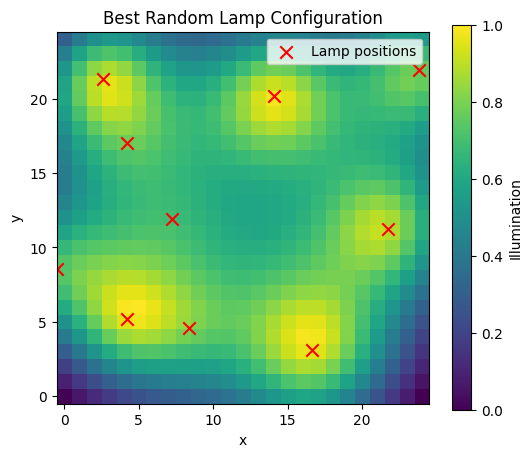

In [62]:
plt.figure(figsize=(6, 5))
plt.imshow(best_l.reshape(grid_size, grid_size), cmap='viridis', origin='lower')
plt.scatter(
    best_lamps[:, 0] - 0.5,
    best_lamps[:, 1] - 0.5,
    color='red',
    marker='x',
    s=80,
    label='Lamp positions'
)
plt.colorbar(label='Illumination')
plt.title('Best Random Lamp Configuration')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

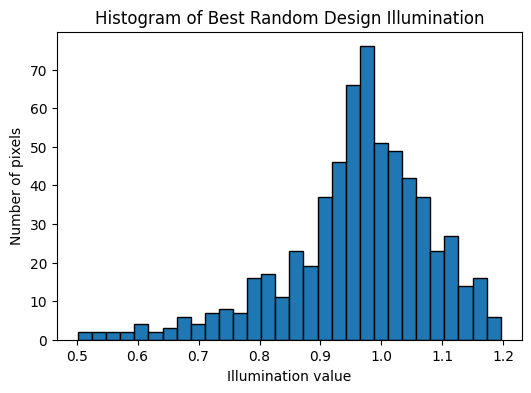

In [63]:
plt.figure(figsize=(6, 4))
plt.hist(best_l, bins=30, edgecolor='black')
plt.title('Histogram of Best Random Design Illumination')
plt.xlabel('Illumination value')
plt.ylabel('Number of pixels')
plt.show()

In [64]:
comparison_design = pd.DataFrame({
    "Case": [
        "Original positions",
        "Best random design"
    ],
    "RMS error": [
        rms_kkt1,
        rms_best
    ],
    "Minimum": [
        min_kkt1,
        min_best
    ],
    "Maximum": [
        max_kkt1,
        max_best
    ],
    "Mean": [
        mean_kkt1,
        mean_best
    ],
    "Standard deviation": [
        std_kkt1,
        std_best
    ]
})

comparison_design.style.format({
    "RMS error": "{:.6f}",
    "Minimum": "{:.6f}",
    "Maximum": "{:.6f}",
    "Mean": "{:.6f}",
    "Standard deviation": "{:.6f}"
})

,Case,RMS error,Minimum,Maximum,Mean,Standard deviation
0,Original positions,0.155559,0.476075,1.268019,0.925871,0.136760
1,Best random design,0.127145,0.502384,1.195634,0.960768,0.120941


The best random lamp configuration found gives an RMS error of **0.127145**. This is smaller than the RMS error of the original lamp configuration under the same total power constraint.

**Original constrained RMS error = 0.155559**

**Best random design RMS error = 0.127145**

This shows that changing the lamp positions can improve the uniformity of the illumination.

The improvement can also be seen by comparing the minimum and maximum illumination values:

| Quantity | Original Configuration | Best Random Configuration |
|---|---:|---:|
| Minimum illumination | 0.476075 | 0.502384 |
| Maximum illumination | 1.268019 | 1.195634 |
| RMS error | 0.155559 | 0.127145 |

The minimum illumination increases from **0.476075** to **0.502384**, meaning that the darkest regions become brighter. At the same time, the maximum illumination decreases from **1.268019** to **1.195634**, meaning that the brightest regions become less intense.

Therefore, the best random design reduces both under-illumination and over-illumination. The illumination values are closer to the desired uniform value of **1**, which explains the lower RMS error.

All lamp powers in the best random design are positive, so the solution is physically meaningful. Also, all lamps satisfy the required position constraints:

**0 ≤ x_j ≤ 25**

**0 ≤ y_j ≤ 25**

**4 ≤ h_j ≤ 6**

This confirms that the best random configuration is a valid design. Overall, the random search successfully found a better lamp placement than the original configuration while keeping the same total power constraint.

## Conclusions

In this assignment, several illumination design methods were compared in order to study how different constraints affect the quality of the lighting pattern.

The baseline case, where all lamp powers were equal to **1**, produced the largest RMS error. Although the average illumination was equal to the desired value, the lighting was not uniform. Some regions were much darker than **1**, while others were much brighter.

The unconstrained least-squares solution improved the illumination significantly. This happened because the optimization was allowed to choose the lamp powers freely in order to minimize the illumination error. As a result, the RMS error decreased and the illumination became more uniform compared with the baseline case.

When equality constraints were added, such as the fixed total power constraint and the balancing constraints, the RMS error increased slightly compared with the unconstrained least-squares solution. This is expected because constraints reduce the freedom of the optimization problem. However, these constrained solutions are still useful because they satisfy additional design requirements, such as fixed energy consumption and better spatial balance.

The exact pixel constraints forced the illumination to be exactly equal to **1** at three selected locations. This made the solution satisfy specific local requirements, but it also slightly increased the global RMS error. This shows the trade-off between satisfying exact illumination conditions at selected points and minimizing the overall illumination error across the whole room.

Finally, the random design challenge showed that changing the lamp positions can improve the illumination quality. The best random configuration achieved a lower RMS error than the original lamp configuration while keeping all lamp powers positive. This means that both lamp placement and lamp power optimization are important for producing a more uniform and physically meaningful illumination design.

Overall, the results show that least-squares optimization is an effective method for illumination design. The unconstrained solution gives the lowest error for fixed lamp positions, while constrained versions are more realistic because they include practical requirements. The best performance was achieved when the lamp positions were also optimized, showing that good placement of the lamps can significantly improve the final illumination pattern.